## 1. Exploration — distributions référence vs prod

=== Shapes & periode ===
reference_set   : (1500, 15)
prod_3months    : (3000, 16) | periode 2026-03-02 00:00:00 -> 2026-05-24 23:00:00
predictions_log : (3000, 5) | periode 2026-03-02 00:00:00 -> 2026-05-24 23:00:00

=== Valeurs manquantes (%) ===
                     reference  prod
loan_amnt                  0.0   0.0
term                       0.0   0.0
int_rate                   0.0   0.0
installment                0.0   0.0
grade                      0.0   0.0
emp_length                 3.3   3.8
home_ownership             0.0   0.0
annual_inc                 0.0   0.0
verification_status        0.0   0.0
purpose                    0.0   0.0
dti                        0.0   0.0
delinq_2yrs                0.0   0.0
fico_range_low             0.0   0.0
revol_util                 1.3   1.2
loan_status                0.0   0.0
timestamp                  NaN   0.0

=== Cible loan_status (%) ===
             reference  prod
loan_status                 
Fully Paid        82.5  80.9
Char

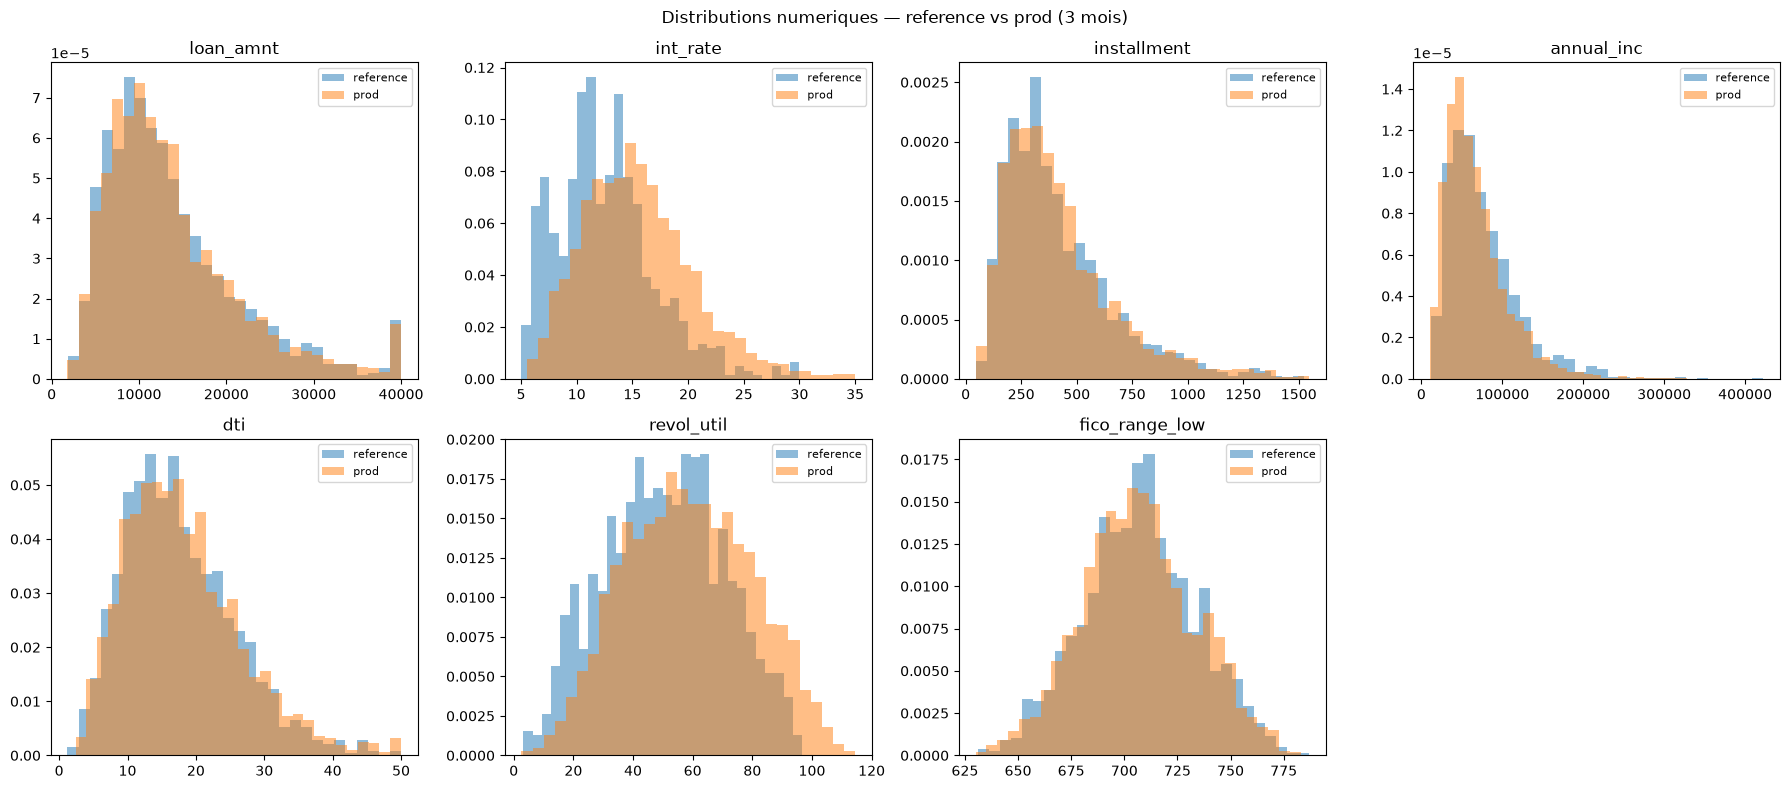

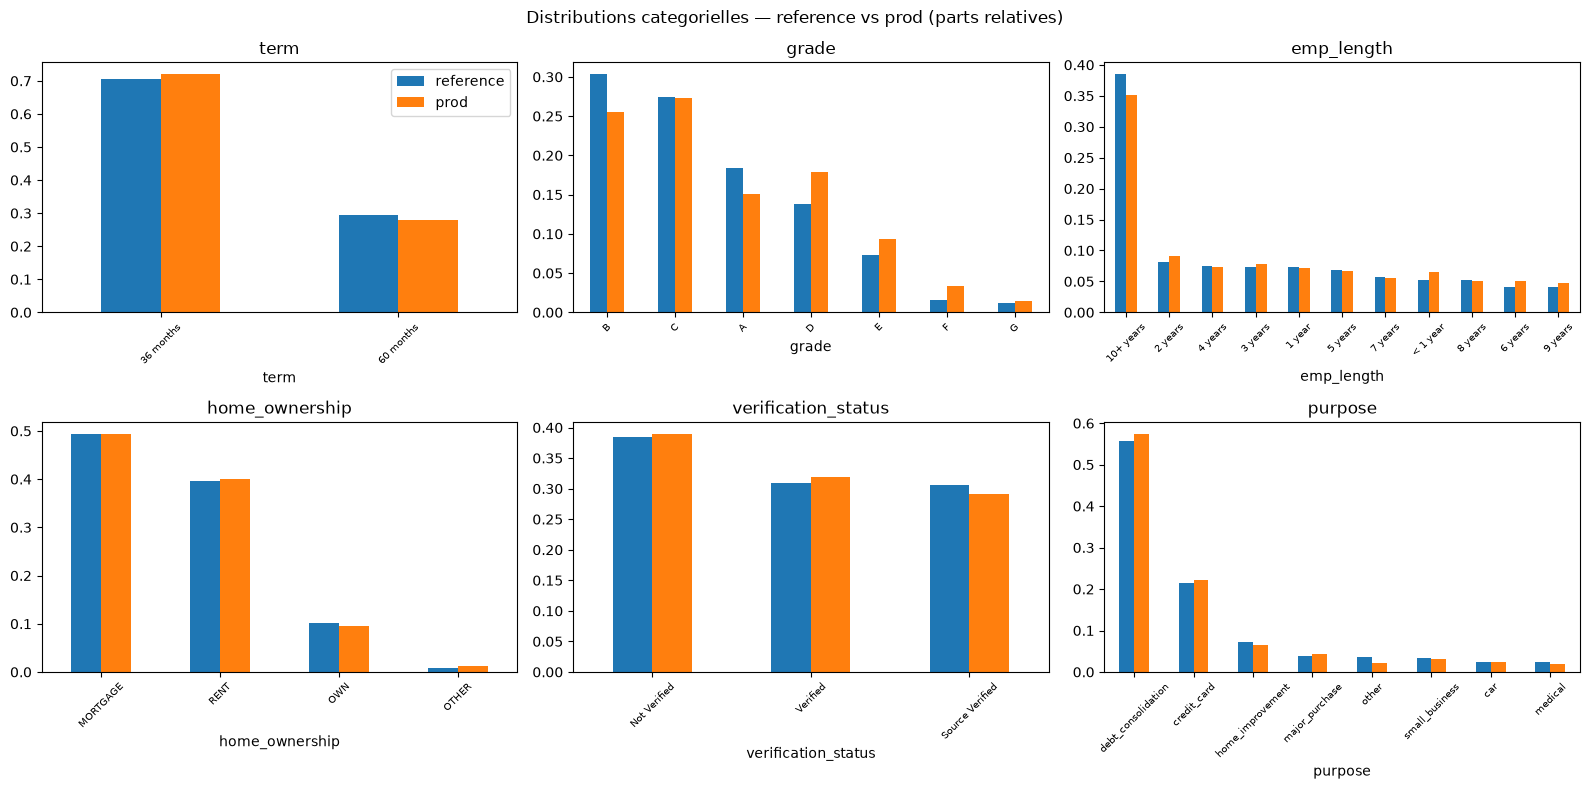

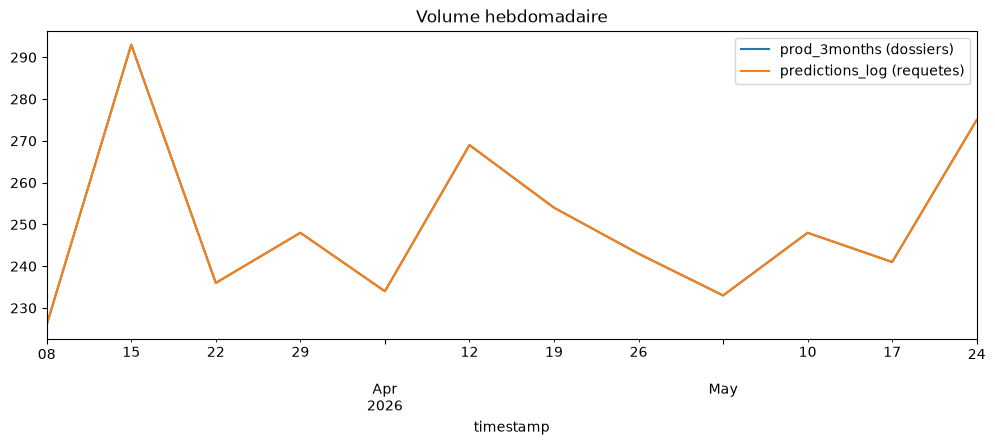

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("..") / "data"

reference = pd.read_csv(DATA_DIR / "reference_set.csv")
prod = pd.read_csv(DATA_DIR / "prod_3months.csv", parse_dates=["timestamp"])
predictions = pd.read_csv(DATA_DIR / "predictions_log.csv", parse_dates=["timestamp"])

NUMERIC_COLS = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "revol_util", "fico_range_low"]
CATEGORICAL_COLS = ["term", "grade", "emp_length", "home_ownership", "verification_status", "purpose"]

print("=== Shapes & periode ===")
print(f"reference_set   : {reference.shape}")
print(f"prod_3months    : {prod.shape} | periode {prod['timestamp'].min()} -> {prod['timestamp'].max()}")
print(f"predictions_log : {predictions.shape} | periode {predictions['timestamp'].min()} -> {predictions['timestamp'].max()}")

print("\n=== Valeurs manquantes (%) ===")
missing = pd.concat(
    {"reference": reference.isna().mean() * 100, "prod": prod.isna().mean() * 100},
    axis=1,
).round(1)
print(missing)

print("\n=== Cible loan_status (%) ===")
target_compare = pd.concat(
    {
        "reference": reference["loan_status"].value_counts(normalize=True) * 100,
        "prod": prod["loan_status"].value_counts(normalize=True) * 100,
    },
    axis=1,
).round(1)
print(target_compare)

print("\n=== predictions_log — taux modele / reel ===")
print(f"taux de prediction=1 (defaut predit) : {predictions['prediction'].mean() * 100:.1f} %")
print(f"taux de true_label=1 (defaut reel)   : {predictions['true_label'].mean() * 100:.1f} %")
print(f"proba_default moyenne                : {predictions['proba_default'].mean():.4f}")

print("\n=== Statistiques descriptives — features numeriques (reference vs prod) ===")
desc = pd.concat(
    {"reference": reference[NUMERIC_COLS].describe(), "prod": prod[NUMERIC_COLS].describe()},
    axis=1,
)
print(desc)

# Distributions numeriques superposees
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), NUMERIC_COLS):
    ax.hist(reference[col].dropna(), bins=30, alpha=0.5, density=True, label="reference")
    ax.hist(prod[col].dropna(), bins=30, alpha=0.5, density=True, label="prod")
    ax.set_title(col)
    ax.legend(fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("Distributions numeriques — reference vs prod (3 mois)")
fig.tight_layout()
plt.show()

# Distributions categorielles (parts relatives)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), CATEGORICAL_COLS):
    ref_pct = reference[col].value_counts(normalize=True)
    prod_pct = prod[col].value_counts(normalize=True)
    compare = pd.concat({"reference": ref_pct, "prod": prod_pct}, axis=1).fillna(0)
    compare.plot(kind="bar", ax=ax, legend=(col == CATEGORICAL_COLS[0]))
    ax.set_title(col)
    ax.tick_params(axis="x", labelsize=7, rotation=45)
fig.suptitle("Distributions categorielles — reference vs prod (parts relatives)")
fig.tight_layout()
plt.show()

# Volume dans le temps
prod_weekly = prod.set_index("timestamp").resample("W").size()
pred_weekly = predictions.set_index("timestamp").resample("W").size()
fig, ax = plt.subplots(figsize=(12, 4))
prod_weekly.plot(ax=ax, label="prod_3months (dossiers)")
pred_weekly.plot(ax=ax, label="predictions_log (requetes)")
ax.set_title("Volume hebdomadaire")
ax.legend()
plt.show()


### Conclusion — exploration

**Volumes et période.** `prod_3months.csv` (3000 dossiers) et `predictions_log.csv`
(3000 requêtes) couvrent la même période, du 2026-03-02 au 2026-05-24, avec un
volume hebdomadaire stable (~230 à 290 dossiers/semaine, pas de rupture visible).
`reference_set.csv` compte 1500 lignes ; les taux de valeurs manquantes
(`emp_length` ~3.3–3.8 %, `revol_util` ~1.2–1.3 %) sont quasi identiques entre
référence et prod : pas de problème de qualité de données côté prod.

**Cible réelle (`loan_status`).** Quasi stable : 17.5 % de défauts en référence
contre 19.1 % en prod. Cet écart est faible et ne suffit pas à lui seul à
expliquer une dérive.

**Indice fort de dérive côté features.** Plusieurs variables numériques se
décalent nettement entre référence et prod :
- `int_rate` : moyenne 12.6 → 15.5 (histogramme visiblement translaté vers la droite) ;
- `revol_util` : moyenne 50.6 → 59.0 ;
- `dti` : 17.6 → 18.2 (léger) ;
- `annual_inc` : 76 938 → 67 156 (revenus déclarés en baisse).

Côté catégoriel, le mix de `grade` se dégrade cohéremment avec la hausse de
`int_rate` : la part de grade B recule (30.5 % → 25.5 %) au profit des grades
D et E (13.9 %→17.6 % et 7.5 %→9.5 %). Les autres variables catégorielles
(`term`, `home_ownership`, `verification_status`, `purpose`, `emp_length`)
restent quasi inchangées. **Ce décalage concerté (int_rate, revol_util, grade)
est le signal de data drift à confirmer statistiquement en partie 2 (PSI/KS/Chi²).**

**Signal fort côté prédictions.** Sur `predictions_log.csv`, le modèle prédit
la classe défaut (`prediction=1`) dans 47.9 % des cas, avec une `proba_default`
moyenne de 0.476 (proche de 0.5, donc quasi indécise), alors que le taux réel
de défaut (`true_label`) n'est que de 19.1 %. Cet écart massif entre le taux
prédit et le taux réel est un signal fort de **miscalibration en production**,
à creuser en partie 3 (calibration) — et interroge aussi la performance du
modèle en partie 4 (le taux de faux positifs semble très élevé).

Trois interprétations possibles à ce stade (à trancher dans les parties suivantes) :

1. **Pas un simple problème de seuil.** Remonter le seuil de décision (>0.5)
   ne suffirait pas à corriger le tir : `proba_default` moyenne à 0.476 pour
   un taux réel de 19 % montre une **miscalibration systématique** sur
   l'ensemble du portefeuille (le modèle « gonfle » ses probabilités de
   défaut), pas seulement un mauvais réglage de coupure sur quelques cas limites.
2. **Conséquence possible du data drift.** Le modèle a été calé sur la
   distribution de référence ; si la prod dérive vers des profils plus
   risqués (`int_rate`, `revol_util`, `grade` en hausse), ses scores peuvent
   se décaler sans que ses probabilités restent fiables — il extrapole hors
   de sa zone de calage.
3. **Possible concept drift.** La relation features → probabilité de défaut
   a pu changer en prod : le modèle « voit » du risque dans les features qui
   ne se matérialise pas autant que prévu en réalité.

Le reliability diagram / ECE (partie 3) et l'évolution de l'AUC dans le temps
(partie 4) permettront de trancher entre ces hypothèses.


## 2. Détection statistique — PSI · KS · Chi²

In [2]:
import sys

sys.path.insert(0, str(Path("..") / "src"))
from drift_detection import PSI_DRIFT, PSI_STABLE, drift_report  # noqa: E402

report = drift_report(reference, prod, NUMERIC_COLS, CATEGORICAL_COLS)


def format_calcul(row: pd.Series) -> str:
    if row["type"] == "numerique":
        return f"PSI={row['psi']:.3f} ; KS p={row['ks_pvalue']:.3g}"
    return f"Chi2 p={row['chi2_pvalue']:.3g}"


def format_interpretation(row: pd.Series) -> str:
    if row["type"] == "numerique":
        if row["psi"] < PSI_STABLE:
            ampleur = "signal faible (PSI < 0.10)"
        elif row["psi"] < PSI_DRIFT:
            ampleur = "à investiguer (PSI 0.10-0.25)"
        else:
            ampleur = "signal fort (PSI > 0.25)"
        detectable = "KS significatif (p<0.05)" if row["ks_pvalue"] < 0.05 else "KS non significatif"
        return f"{ampleur} ; {detectable}"
    if row["chi2_pvalue"] < 0.05:
        return "Chi² significatif (p<0.05) : répartition des modalités différente"
    return "Chi² non significatif : répartition des modalités stable"


report["calcul"] = report.apply(format_calcul, axis=1)
report["interpretation"] = report.apply(format_interpretation, axis=1)

print("=== Tableau de synthèse — PSI · KS · Chi² (trié par sévérité) ===")
print(report[["feature", "type", "calcul", "verdict", "interpretation"]].to_string(index=False))

# Ecriture de drift_summary.md : colonnes "calcul" et "interpretation" distinctes
md_lines = [
    "# Synthèse drift — PSI · KS · Chi²",
    "",
    "Repères conventionnels PSI : < 0.10 signal faible, 0.10–0.25 signal à investiguer, > 0.25 signal fort.",
    "Ce sont des heuristiques de place, pas des lois statistiques : un chiffre n'est pas un verdict.",
    "",
    "| Feature | Type | Calcul | Verdict | Interprétation |",
    "|---|---|---|---|---|",
]
for _, row in report.iterrows():
    md_lines.append(
        f"| `{row['feature']}` | {row['type']} | {row['calcul']} | {row['verdict']} | {row['interpretation']} |"
    )

drift_summary_path = Path("..") / "drift_summary.md"
drift_summary_path.write_text("\n".join(md_lines) + "\n", encoding="utf-8")
print(f"\nEcrit : {drift_summary_path.resolve()}")


=== Tableau de synthèse — PSI · KS · Chi² (trié par sévérité) ===
            feature         type                    calcul verdict                                                    interpretation
           int_rate    numerique PSI=0.444 ; KS p=4.63e-65  dérive               signal fort (PSI > 0.25) ; KS significatif (p<0.05)
              grade categorielle           Chi2 p=3.65e-07  dérive Chi² significatif (p<0.05) : répartition des modalités différente
         revol_util    numerique PSI=0.187 ; KS p=3.82e-20 suspect          à investiguer (PSI 0.10-0.25) ; KS significatif (p<0.05)
         annual_inc    numerique PSI=0.067 ; KS p=2.28e-09  stable             signal faible (PSI < 0.10) ; KS significatif (p<0.05)
        installment    numerique    PSI=0.015 ; KS p=0.663  stable                  signal faible (PSI < 0.10) ; KS non significatif
                dti    numerique     PSI=0.011 ; KS p=0.11  stable                  signal faible (PSI < 0.10) ; KS non significatif
   

### Conclusion — détection statistique (PSI · KS · Chi²)

#### Pour rappel, à quoi servent ces 3 indicateurs ?

- **PSI (Population Stability Index)** — répond à *« l'écart est-il gros ou
  petit ? »*. On découpe la référence en 10 tranches et on regarde comment la
  prod se répartit dans ces mêmes tranches. C'est un **chiffre continu**, pas
  un test statistique : repères conventionnels **< 0.10 = signal faible,
  0.10–0.25 = à investiguer, > 0.25 = signal fort**. Ne s'applique qu'aux
  variables **numériques**.
- **KS (Kolmogorov-Smirnov)** — répond à *« cet écart pourrait-il être dû au
  hasard d'échantillonnage ? »*. Résultat : une **p-value** (< 0.05 = écart
  jugé réel, pas du bruit). ⚠️ Très sensible dès qu'on a beaucoup de lignes :
  il peut signaler comme « significatif » un écart en réalité minuscule.
  S'applique aux variables **numériques**.
- **Chi²** — l'équivalent du KS mais pour les variables **catégorielles**
  (`grade`, `term`, ...) : il compare, catégorie par catégorie, le nombre de
  dossiers observés en prod au nombre attendu si la répartition de la
  référence n'avait pas changé. Résultat aussi une **p-value** (< 0.05 =
  répartition des catégories différente).

**Règle d'or : on ne conclut jamais avec un seul chiffre.** PSI donne
l'ampleur, KS/Chi² confirment que ce n'est pas juste du bruit statistique.
Le tableau de synthèse (écrit dans `drift_summary.md`, colonnes **calcul** et
**interprétation** distinctes) croise ces indicateurs pour chaque feature :

- **`int_rate` (taux d'intérêt) : dérive forte.** PSI = 0.444 (bien au-dessus
  du seuil de 0.25) et KS p ≈ 5·10⁻⁶⁵ (quasi nul) : les deux méthodes sont
  d'accord, c'est la feature qui a le plus bougé entre référence et prod.
- **`grade` (catégorie de risque) : dérive.** Chi² p ≈ 3.7·10⁻⁷ : la
  répartition des grades a réellement changé (moins de bons profils B, plus
  de profils risqués D/E), ce n'est pas un hasard d'échantillonnage.
- **`revol_util` (taux d'utilisation du crédit renouvelable) : à
  investiguer.** PSI = 0.187, dans la zone intermédiaire 0.10–0.25, et KS
  significatif : un écart réel, mais moins marqué que celui d'`int_rate`.
- **`annual_inc` (revenu annuel) : signal faible malgré un KS très
  significatif** (p ≈ 2.3·10⁻⁹). C'est l'exemple parfait du piège à éviter :
  avec 1500 vs 3000 lignes, le KS détecte presque n'importe quel petit écart.
  Ici le PSI reste sous 0.10 (0.067) : l'écart est réel mais **trop petit pour
  être qualifié de dérive** — on se fie à l'ampleur (PSI), pas à la seule
  p-value.
- **Toutes les autres features (`installment`, `dti`, `fico_range_low`,
  `loan_amnt`, `term`, `emp_length`, `home_ownership`,
  `verification_status`, `purpose`) sont stables** : ni PSI, ni KS/Chi²
  significatifs.

**Synthèse globale, en une phrase.** La dérive n'est pas généralisée à tout
le jeu de données : elle est **concentrée sur 2 à 3 variables liées au risque
de crédit** (`int_rate`, `grade`, et dans une moindre mesure `revol_util`),
ce qui ressemble à un changement de mix de population (des profils plus
risqués arrivent en prod) plutôt qu'à un problème de qualité de données. Ce
diagnostic — **data drift localisé vs concept drift** — sera affiné en
partie 3 (calibration) et partie 4 (évolution de l'AUC dans le temps).


## 3. Calibration en exploitation

Semaines couvertes par predictions_log.csv : 1 a 12
Semaines 1-4  : 1003 requetes | taux reel de defaut = 20.2 %
Semaines 9-12 : 997 requetes | taux reel de defaut = 20.1 %

ECE global (3 mois)  : 0.2844
ECE semaines 1-4      : 0.2403
ECE semaines 9-12     : 0.3152

=== Reliability table — global ===
          bin   n  confiance_moyenne  taux_observe    ecart
(-0.001, 0.1]  18           0.082472      0.000000 0.082472
   (0.1, 0.2] 157           0.157098      0.006369 0.150729
   (0.2, 0.3] 309           0.253964      0.038835 0.215129
   (0.3, 0.4] 462           0.351020      0.082251 0.268769
   (0.4, 0.5] 618           0.450846      0.137540 0.313306
   (0.5, 0.6] 727           0.552143      0.236589 0.315555
   (0.6, 0.7] 446           0.641663      0.302691 0.338972
   (0.7, 0.8] 255           0.735839      0.490196 0.245643
   (0.8, 0.9]   8           0.819538      0.750000 0.069538


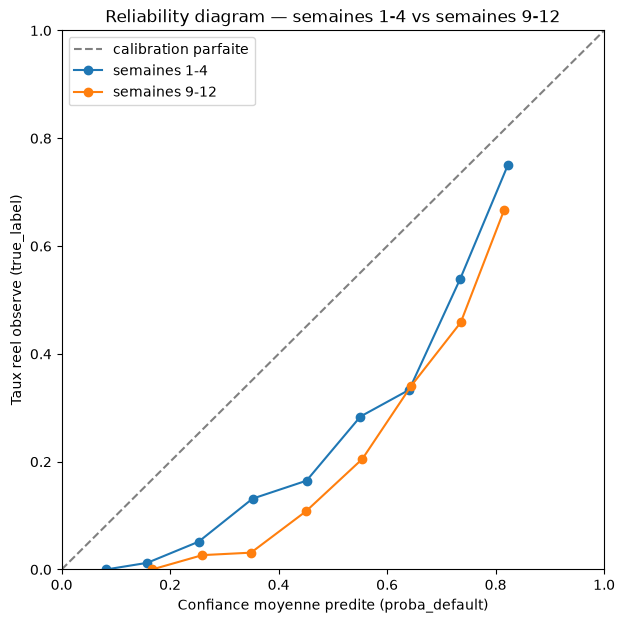

In [3]:
import sys

sys.path.insert(0, str(Path("..") / "src"))
from calibration import expected_calibration_error, reliability_table  # noqa: E402

# Fenetre : la calibration exige les vrais labels -> mesuree en differe (voir mini-cours 03)
predictions["week"] = ((predictions["timestamp"] - predictions["timestamp"].min()).dt.days // 7) + 1
print(f"Semaines couvertes par predictions_log.csv : {predictions['week'].min()} a {predictions['week'].max()}")

early = predictions[predictions["week"].between(1, 4)]
late = predictions[predictions["week"].between(9, 12)]
print(f"Semaines 1-4  : {len(early)} requetes | taux reel de defaut = {early['true_label'].mean() * 100:.1f} %")
print(f"Semaines 9-12 : {len(late)} requetes | taux reel de defaut = {late['true_label'].mean() * 100:.1f} %")

table_all = reliability_table(predictions["proba_default"], predictions["true_label"])
table_early = reliability_table(early["proba_default"], early["true_label"])
table_late = reliability_table(late["proba_default"], late["true_label"])

ece_all = expected_calibration_error(predictions["proba_default"], predictions["true_label"])
ece_early = expected_calibration_error(early["proba_default"], early["true_label"])
ece_late = expected_calibration_error(late["proba_default"], late["true_label"])

print(f"\nECE global (3 mois)  : {ece_all:.4f}")
print(f"ECE semaines 1-4      : {ece_early:.4f}")
print(f"ECE semaines 9-12     : {ece_late:.4f}")

print("\n=== Reliability table — global ===")
print(table_all[["bin", "n", "confiance_moyenne", "taux_observe", "ecart"]].to_string(index=False))

# Reliability diagram : X = confiance moyenne predite, Y = taux reel observe
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="calibration parfaite")
ax.plot(table_early["confiance_moyenne"], table_early["taux_observe"], marker="o", label="semaines 1-4")
ax.plot(table_late["confiance_moyenne"], table_late["taux_observe"], marker="o", label="semaines 9-12")
ax.set_xlabel("Confiance moyenne predite (proba_default)")
ax.set_ylabel("Taux reel observe (true_label)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Reliability diagram — semaines 1-4 vs semaines 9-12")
ax.legend()
plt.show()


### Conclusion — calibration en exploitation

#### Rappel : comment lire le reliability diagram ?

On découpe les probabilités prédites (`proba_default`) en tranches, et pour
chaque tranche on compare : **axe X = confiance moyenne annoncée par le
modèle**, **axe Y = taux réel de défaut observé** (`true_label`). Un modèle
parfaitement calibré suit la diagonale (proba annoncée = taux réel). Une
courbe **sous la diagonale = sur-confiance** (le modèle annonce plus de
risque qu'il n'y en a réellement) ; **au-dessus = sous-confiance**.

⚠️ Ces courbes sont mesurées en différé : `true_label` n'est connu qu'une fois
le prêt arrivé à échéance, donc on regarde toujours une fenêtre passée, jamais
la production du jour.

#### Ce qu'on observe

**Le modèle est nettement sur-confiant, sur toute la plage de score.** Les
deux courbes (semaines 1-4 et semaines 9-12) sont **systématiquement sous la
diagonale** : quand le modèle annonce 50 % de risque, le taux réel observé
n'est que de ~14–24 % ; quand il annonce 80 %, le taux réel n'est que de
~50–75 %. Ça confirme et explique le signal repéré en partie 1 : une
`proba_default` moyenne de 0.476 pour un taux réel de défaut de 19 %.

**La calibration se dégrade dans le temps.** L'ECE passe de **0.240**
(semaines 1-4) à **0.315** (semaines 9-12), avec un taux réel de défaut quasi
identique entre les deux périodes (20.2 % vs 20.1 %). Le modèle n'est donc
pas seulement mal calibré dès le départ : **il devient de plus en plus
sur-confiant au fil des 3 mois**, alors que le taux de base réel ne bouge pas.

**Lien avec le drift détecté en partie 2.** Cette dégradation progressive de
la calibration, combinée à une dérive concentrée sur `int_rate`/`grade`/
`revol_util`, est cohérente avec un **data drift qui pousse le modèle à
extrapoler hors de sa zone de calage** plutôt qu'avec un simple biais constant
de conception. Reste à vérifier en partie 4 si l'AUC (le pouvoir de tri) tient
malgré cette sur-confiance — ce qui trancherait entre data drift (AUC stable,
scores juste décalés) et concept drift (AUC qui se dégrade aussi).


## 4. Performance dans le temps

AUC semaines 1-4  : 0.7419
AUC semaines 9-12 : 0.7459
Delta AUC (fin - debut) : +0.0040
Verdict AUC : stable (|delta| < 0.03)

=== Performance semaine par semaine ===
 week   n      auc       f1  taux_reel
    1 226 0.716351 0.455882   0.212389
    2 293 0.777211 0.445860   0.163823
    3 236 0.737675 0.488095   0.241525
    4 248 0.720909 0.447205   0.201613
    5 234 0.739908 0.402878   0.166667
    6 269 0.726712 0.393064   0.185874
    7 254 0.716962 0.379085   0.169291
    8 243 0.759301 0.420382   0.160494
    9 233 0.798033 0.502924   0.214592
   10 248 0.756731 0.382022   0.161290
   11 241 0.731818 0.468750   0.228216
   12 275 0.708182 0.435556   0.200000


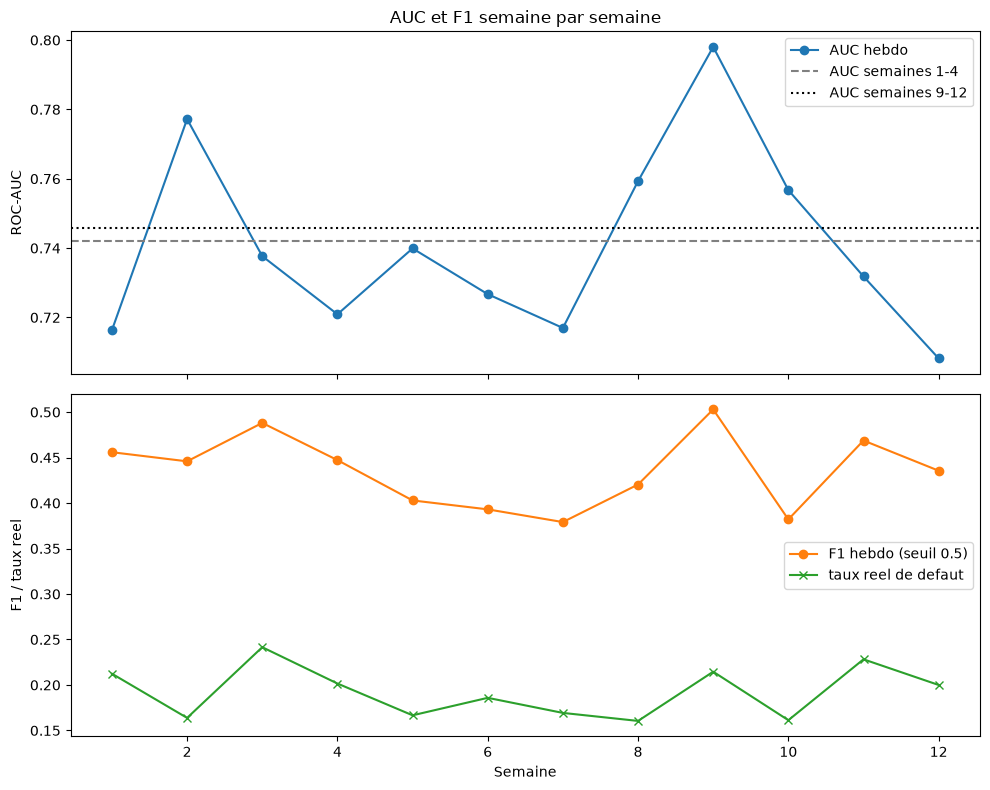

In [5]:
from sklearn.metrics import f1_score, roc_auc_score

auc_early = roc_auc_score(early["true_label"], early["proba_default"])
auc_late = roc_auc_score(late["true_label"], late["proba_default"])
delta_auc = auc_late - auc_early

print(f"AUC semaines 1-4  : {auc_early:.4f}")
print(f"AUC semaines 9-12 : {auc_late:.4f}")
print(f"Delta AUC (fin - debut) : {delta_auc:+.4f}")
print("Verdict AUC :", "stable (|delta| < 0.03)" if abs(delta_auc) < 0.03 else "instable (|delta| >= 0.03)")

# Vue fine semaine par semaine : AUC + F1 (seuil 0.5) pour distinguer tendance vs rupture brutale
weekly_rows = []
for week, grp in predictions.groupby("week"):
    weekly_rows.append(
        {
            "week": week,
            "n": len(grp),
            "auc": roc_auc_score(grp["true_label"], grp["proba_default"]),
            "f1": f1_score(grp["true_label"], grp["prediction"]),
            "taux_reel": grp["true_label"].mean(),
        }
    )
weekly = pd.DataFrame(weekly_rows).sort_values("week")
print("\n=== Performance semaine par semaine ===")
print(weekly.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(weekly["week"], weekly["auc"], marker="o", label="AUC hebdo")
axes[0].axhline(auc_early, linestyle="--", color="grey", label="AUC semaines 1-4")
axes[0].axhline(auc_late, linestyle=":", color="black", label="AUC semaines 9-12")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("AUC et F1 semaine par semaine")
axes[0].legend()

axes[1].plot(weekly["week"], weekly["f1"], marker="o", color="tab:orange", label="F1 hebdo (seuil 0.5)")
axes[1].plot(weekly["week"], weekly["taux_reel"], marker="x", color="tab:green", label="taux reel de defaut")
axes[1].set_xlabel("Semaine")
axes[1].set_ylabel("F1 / taux reel")
axes[1].legend()
plt.tight_layout()
plt.show()


### Conclusion — performance dans le temps & fiche de diagnostic

#### Pourquoi l'AUC et pas le F1 pour ce diagnostic ?

L'**AUC** mesure le pouvoir de tri du modèle **indépendamment du seuil de
décision** : elle répond à *« le modèle sait-il encore ordonner les bons et
mauvais profils ? »*. Le **F1** dépend du seuil choisi (ici 0.5) — or on a vu
en partie 3 que le modèle est sur-confiant : son F1 peut donc bouger juste à
cause d'un problème de seuil/calibration, sans que le pouvoir de tri change.
C'est pour ça que le mini-cours 02 dit : *« Conclure concept drift parce que
le F1 baisse » est un piège — on regarde l'AUC en premier*.

#### Résultats

- **AUC semaines 1-4 : 0.742** — **AUC semaines 9-12 : 0.746** — **ΔAUC =
  +0.004**, très en-dessous du seuil de 0.03 → **AUC stable**.
- La vue semaine par semaine confirme : l'AUC hebdomadaire oscille entre
  0.71 et 0.80 **sans tendance de fond ni rupture brutale** — les variations
  ressemblent à du bruit d'échantillonnage (~250 dossiers/semaine) plutôt qu'à
  une dérive du pouvoir de tri.
- Le F1 hebdomadaire (seuil 0.5) et le taux réel de défaut fluctuent eux aussi
  sans dégradation nette sur 12 semaines.

#### Fiche de diagnostic (mini-cours 02)

```text
Features qui dérivent : int_rate (PSI=0.444, dérive forte), grade (Chi² p≈3.7e-7, dérive),
                         revol_util (PSI=0.187, à investiguer)
AUC début : 0.742     AUC fin : 0.746     ΔAUC : +0.004 (stable, |Δ|<0.03)
Calibration début → fin : sur-confiance sur toute la plage, qui s'aggrave (ECE 0.240 -> 0.315)
Temporalité : [x] tendance progressive (calibration)   [ ] rupture brutale
              AUC : ni tendance ni rupture, fluctuation stable autour de ~0.74

Diagnostic retenu (cocher) :
[ ] pas de signal significatif
[x] data drift plausible
[x] impact sur la calibration
[ ] concept drift à investiguer
[ ] problème de qualité / ETL à investiguer

Preuves qui soutiennent ce diagnostic :
- Dérive concentrée sur 2-3 features liées au risque (int_rate, grade, revol_util),
  cohérente entre elles (grades plus risques -> taux plus eleves) ;
- AUC stable sur 3 mois -> le modele ordonne toujours correctement les profils ;
- Calibration degradee de facon progressive (pas de saut), coherente avec un
  glissement continu de la population plutot qu'un choc/bug ETL.

Ce qui manquerait pour etre certain :
- Un historique plus long pour confirmer que la tendance de calibration se
  poursuit (ou se stabilise) au-dela de S12 ;
- Une comparaison a un jeu externe pour ecarter un biais propre a predictions_log.csv ;
- Un test de stabilite du modele sur un sous-echantillon recalibre pour verifier
  que le recalage seul suffit a corriger le F1, sans reentrainement complet.
```

**Conclusion tranchée.** Le triangle features-dérivent + AUC-stable +
calibration-dégradée correspond exactement au cas **« data drift plausible »**
de la matrice de diagnostic (mini-cours 02) : la population de production
glisse vers des profils plus risqués (`int_rate`, `grade`, `revol_util`), le
modèle continue de bien **ordonner** ces profils (AUC stable) mais ses
**probabilités** ne sont plus fiables (sur-confiance croissante). Rien
n'indique à ce stade un changement de la relation features → risque
(concept drift) : la remédiation à privilégier est un **recalage /
réentraînement sur données récentes** pour corriger la calibration, pas une
remise en cause du modèle lui-même. 


## 5. Diagnostic & recommandation

In [ ]:
# TODO
